In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fisheye
import uproot as up
import pandas as pd
import awkward as ak

import matplotlib.cm as cm

import importlib
importlib.reload(fisheye)

<module 'fisheye' from 'c:\\Users\\bglen\\Research\\XLZD\\Fisheye\\fisheye.py'>

In [58]:
camera = fisheye.Fisheye(distance_to_object_cm=11.15, field_of_view_radius_cm=10., projection_type='adam_01')

camera.PrintInfo()
camera.DefineSensor(pixel_size_mm=0.0074, num_pixels_x=1024*4, num_pixels_y=1024*4)
camera.CalculateFocalLength()

Distance to object: 11.15 cm
Field of view radius: 10.00 cm
Field of view angle: 41.89 degrees
Projection type: adam_01
Array size: 30.31 mm x 30.31 mm
Max image radius: 15.16 mm
Pixel size: 0.01 mm
Number of pixels: 4096 x 4096


(0.0, 10.0)

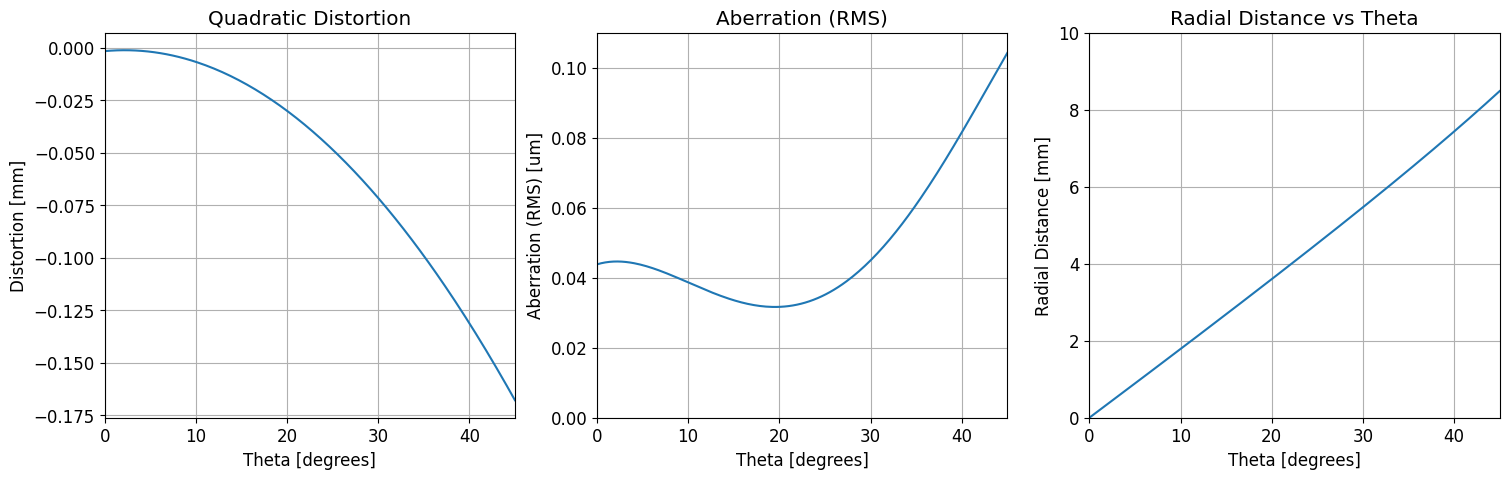

In [59]:
# Plot the distortion curve and aberration for the 'adam_01' projection type.

# Make a two-panel plot: one for distortion and one for aberration.
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

thetas = np.linspace(0.,45.,200)
axs[0].plot(thetas, camera._quadratic_distortion(thetas))
axs[0].set_xlabel('Theta [degrees]')
axs[0].set_ylabel('Distortion [mm]')
axs[0].set_title('Quadratic Distortion')
axs[0].grid()
axs[0].set_xlim(0, 45)

axs[1].plot(thetas, camera._aberration_rms(thetas))
axs[1].set_xlabel('Theta [degrees]')
axs[1].set_ylabel('Aberration (RMS) [um]')
axs[1].set_title('Aberration (RMS)')
axs[1].grid()
axs[1].set_xlim(0, 45)
axs[1].set_ylim(0, .11)

axs[2].plot(thetas, 10.19619 * np.tan(thetas/180* np.pi) * (1 + camera._quadratic_distortion(thetas)))
axs[2].set_xlabel('Theta [degrees]')
axs[2].set_ylabel('Radial Distance [mm]')
axs[2].set_title('Radial Distance vs Theta')
axs[2].grid()
axs[2].set_xlim(0, 45)
axs[2].set_ylim(0, 10.)

10.0


Text(0.5, 1.0, 'Zoomed in view of the center of the sensor plane\n (2D histogram of point density)')

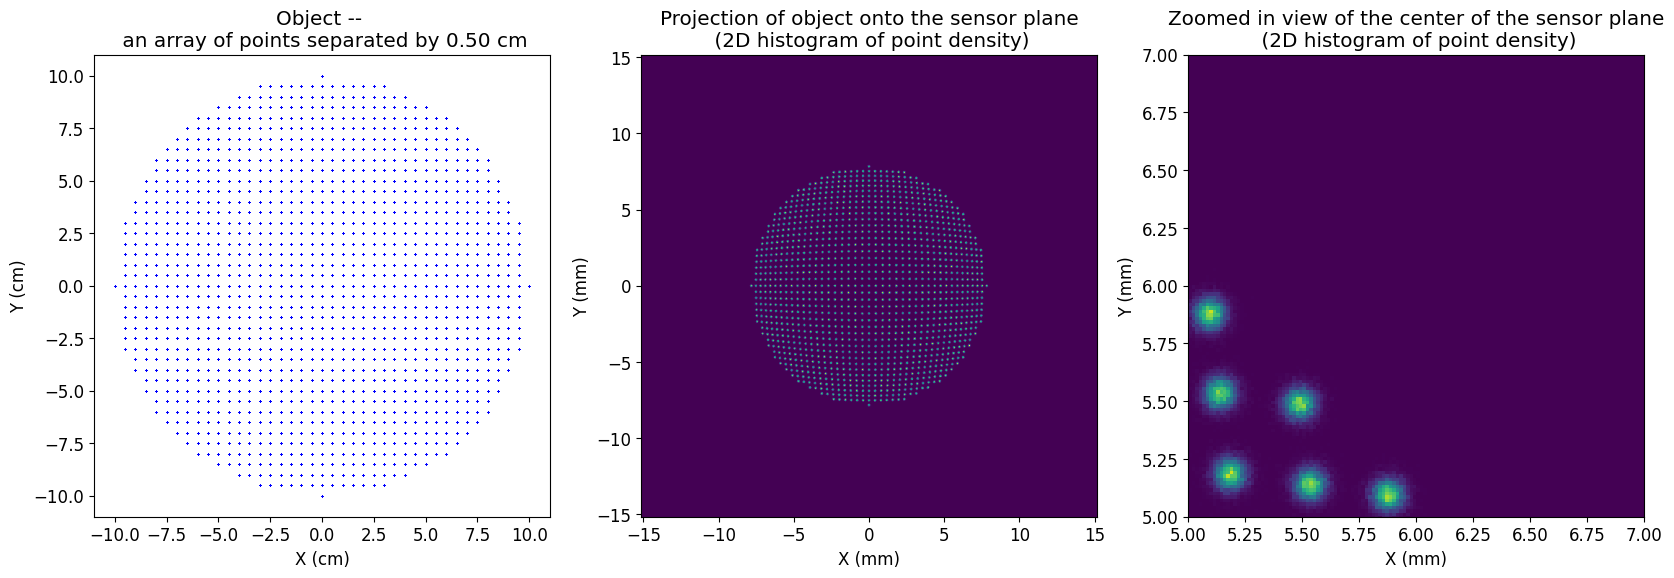

In [60]:
# Define my object as a grid of points in 2D space (the object plane), each weighted by one.
plt.rcParams['font.size'] = 12

fig, axs = plt.subplots(1, 3, figsize=(20, 6))
# plt.figure(figsize=(8, 8))

point_spacing_cm = 0.5 # cm
print(camera.field_of_view_radius_cm)
object_plane_x = np.arange(-camera.field_of_view_radius_cm, camera.field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)
object_plane_y = np.arange(-camera.field_of_view_radius_cm, camera.field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)
#make 20 identical copies of each array and concatenate them to make a denser grid of points.
object_plane_x = np.concatenate([object_plane_x for i in range(100)])
object_plane_y = np.concatenate([object_plane_y for i in range(100)])

object_plane_X, object_plane_Y = np.meshgrid(object_plane_x, object_plane_y)
mask = np.sqrt(object_plane_X**2 + object_plane_Y**2) <= camera.field_of_view_radius_cm
object_plane_X = object_plane_X[mask]
object_plane_Y = object_plane_Y[mask]

axs[0].plot(object_plane_X, object_plane_Y, 'o', markersize=1, color='blue', markeredgecolor='none')
axs[0].set_title('Object -- \n an array of points separated by {:.2f} cm'.format(point_spacing_cm))
axs[0].set_xlabel('X (cm)')
axs[0].set_ylabel('Y (cm)')
axs[0].set_xlim(-camera.field_of_view_radius_cm - 1, camera.field_of_view_radius_cm + 1)
axs[0].set_ylim(-camera.field_of_view_radius_cm - 1, camera.field_of_view_radius_cm + 1)
# plt.grid()

# Flatten the grid to get a list of points. the Z coordinate is just the distance to the object plane, which is constant for all points.
object_points_3d = np.column_stack((object_plane_X.flatten(), object_plane_Y.flatten(), np.ones(object_plane_X.size) * camera.distance_to_object_cm))
object_weights_3d = np.ones(object_points_3d.shape[0]) # All points have equal weight for now.


camera.DefineObject(object_points_3d, object_weights_3d)
camera.ProjectPoints( aberration=True)


# Make the same plot above, but a 2D histogram (heatmap) of the image points to show the density of points in different regions of the sensor plane.
axs[1].hist2d(camera.image_points_2d_mm[:, 0], camera.image_points_2d_mm[:, 1], \
                bins=2000, range=[[-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm], \
                                    [-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm]], \
                cmap='viridis')
axs[1].set_title('Projection of object onto the sensor plane\n (2D histogram of point density)')
axs[1].set_xlabel('X (mm)')
axs[1].set_ylabel('Y (mm)')



axs[2].hist2d(camera.image_points_2d_mm[:, 0], camera.image_points_2d_mm[:, 1], bins=2000, \
            range=[[-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm], \
                    [-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm]], \
            cmap='viridis')
# plt.title('Projection of object onto the sensor plane\n (2D histogram of point density)')
axs[2].set_xlabel('X (mm)')
axs[2].set_ylabel('Y (mm)')
axs[2].set_xlim(5.,7.)
axs[2].set_ylim(5.,7.)
axs[2].set_title('Zoomed in view of the center of the sensor plane\n (2D histogram of point density)')

In [61]:
track_length_cm = 0.4
track_angle_phi_deg = 0
diffusion_sigma_um = 10
z_min_mm = 0.0
z_max_mm = 5.
track_offset_x_cm = 0.0
track_offset_y_cm = 0.0

# Build a short vertical track in +y with uniform deposited energy per sample point.
upsampling_factor = 20
n_photons = 2500*upsampling_factor
n_track_points = 500
photons_per_energy = n_photons / n_track_points

track_y_cm = np.linspace(-track_length_cm/2, track_length_cm/2, n_track_points) + track_offset_y_cm
track_x_cm = np.full(n_track_points, track_offset_x_cm)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

source_out = camera.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=photons_per_energy,
    kernel_sigma_um=diffusion_sigma_um,
    z_min_mm=0.0,
    z_max_mm=0.1,
    count_mode='deterministic',
    rng_seed=123
 )
print(source_out['metadata'])

{'n_input_points': 500, 'n_valid_points': 500, 'n_generated_photons': 50000, 'count_mode': 'deterministic', 'kernel_sigma_um': 10.0, 'z_range_mm': [0.0, 0.1], 'rng_seed': 123}


In [62]:
def FourPanelPlot(camera, track_x_cm, track_y_cm, upsampling_factor):
    # Visualize photon origins in object space (x-y).
    fig, axs = plt.subplots(2, 2, figsize=(11, 9))
    fig.subplots_adjust(left=0.10, right=0.95, bottom=0.10, top=0.92,
                        wspace=0.35, hspace=0.35)

    axs[0, 0].set_box_aspect(1)
    axs[0, 1].set_box_aspect(1)

    fig_w_in = 12
    dx_in = 0.45
    dx = dx_in / fig_w_in   # figure-fraction shift

    for ax in (axs[0, 0], axs[0, 1]):
        x0, y0, w, h = ax.get_position().bounds
        ax.set_position([x0 - dx, y0, w, h])
        
    # Get x and y boundaries of the track. 
    x_min, x_max = track_x_cm.min(), track_x_cm.max()
    y_min, y_max = track_y_cm.min(), track_y_cm.max()
    # Choose the larger of the two and add 10% padding on each side for the axis limits.
    max_range = max(x_max - x_min, y_max - y_min)
    x_center = (x_max + x_min) / 2
    y_center = (y_max + y_min) / 2
    

    axs[0, 0].scatter(camera.object_points_3d[:, 0], camera.object_points_3d[:, 1], s=0.5, alpha=0.25)
    axs[0, 0].plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Input track centerline')
    axs[0, 0].set_xlabel('X (cm)')
    axs[0, 0].set_ylabel('Y (cm)')
    axs[0, 0].set_xlim(x_center - max_range/2*1.1, x_center + max_range/2*1.1)
    axs[0, 0].set_ylim(y_center - max_range/2*1.1, y_center + max_range/2*1.1)
    # axs[0, 0].set_title('Sampled photon origins from simple {:2.2} cm track'.format(track_y_cm[-1] - track_y_cm[0]))
    axs[0,0].set_title('Original track')
    axs[0, 0].legend()
    
    
    # Find the spatial extent of the image points that have nonzero photon counts to set the axis limits for the image projection plot.
    x_min_mm, x_max_mm = camera.image_points_2d_mm[:, 0].min(), camera.image_points_2d_mm[:, 0].max()
    y_min_mm, y_max_mm = camera.image_points_2d_mm[:, 1].min(), camera.image_points_2d_mm[:, 1].max()
    max_range_mm = max(x_max_mm - x_min_mm, y_max_mm - y_min_mm)
    x_center_mm = (x_max_mm + x_min_mm) / 2
    y_center_mm = (y_max_mm + y_min_mm) / 2
    
    axs[0,1].hist2d(camera.image_points_2d_mm[:, 0], camera.image_points_2d_mm[:, 1], bins=2000, range=[[-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm], [-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm]], cmap='viridis')
    # axs[1,1].set_title('Projection of object onto the sensor plane\n (2D histogram of point density)')
    axs[0,1].set_title('Image projection')
    axs[0,1].set_xlabel('X (mm)')
    axs[0,1].set_ylabel('Y (mm)')
    # Note that I can use the same max_range and center as the original track, since the magnification is roughly 1:10 and I'm changing units from cm to mm.
    axs[0,1].set_xlim(x_center_mm - max_range_mm/2*1.1, x_center_mm + max_range_mm/2*1.1)
    axs[0,1].set_ylim(y_center_mm - max_range_mm/2*1.1, y_center_mm + max_range_mm/2*1.1)
    
    # Set the x-lim and y-lim of the sensor image plots to match the above, but in pixel coordinates.
    pixels_per_mm = camera.sensor.num_pixels_x / (2 * camera.sensor.max_image_radius_mm)
    x_center_pix = pixels_per_mm * x_center_mm + camera.sensor.num_pixels_x / 2
    y_center_pix = pixels_per_mm * y_center_mm + camera.sensor.num_pixels_y / 2
    max_range_pix = max_range_mm * pixels_per_mm


    im01 = axs[1,0].imshow(camera.sensor_image/upsampling_factor, origin='lower', aspect='auto')
    # axs[0,1].set_title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm Gaussian diffusion, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], diffusion_sigma_um/1000, z_max_mm-z_min_mm))
    axs[1,0].set_title('Sensor image')
    axs[1,0].set_xlabel('Pixel X')
    axs[1,0].set_ylabel('Pixel Y')
    # axs[1,0].set_xlim(x_center_pix - max_range_pix/2*1.1, x_center_pix + max_range_pix/2*1.1)
    # axs[1,0].set_ylim(y_center_pix - max_range_pix/2*1.1, y_center_pix + max_range_pix/2*1.1)
    fig.colorbar(im01, label='Photon count', ax=axs[1,0])
    
    

    im10 = axs[1,1].imshow(camera.sensor_image/upsampling_factor, origin='lower', aspect='auto')
    # axs[1,0].set_title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm Gaussian diffusion, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], diffusion_sigma_um/1000, z_max_mm-z_min_mm))
    axs[1,1].set_title('Sensor image (zoomed)')
    axs[1,1].set_xlabel('Pixel X')
    axs[1,1].set_ylabel('Pixel Y')
    axs[1,1].set_xlim(x_center_pix - max_range_pix/2*1.1, x_center_pix + max_range_pix/2*1.1)
    axs[1,1].set_ylim(y_center_pix - max_range_pix/2*1.1, y_center_pix + max_range_pix/2*1.1)
    fig.colorbar(im10, label='Photon count', ax=axs[1,1])



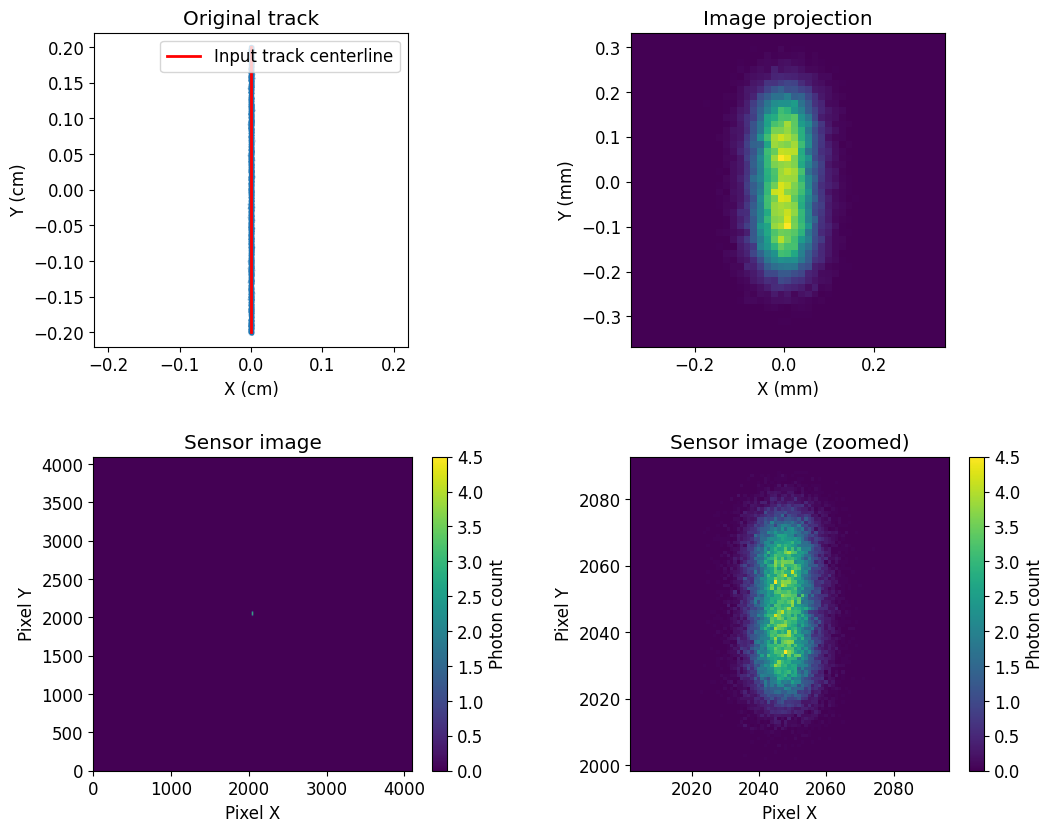

In [63]:
# --- Project and render ---
camera.ProjectPoints(aberration=True)
camera.ProduceImage()
FourPanelPlot(camera, track_x_cm, track_y_cm, upsampling_factor)

In [68]:
track_length_cm = 0.4
track_angle_phi_deg = 0
diffusion_sigma_um = 10
z_min_mm = 0.0
z_max_mm = 5.
track_offset_x_cm = -10.
track_offset_y_cm = 0.0

# Build a short vertical track in +y with uniform deposited energy per sample point.
upsampling_factor = 20
n_photons = 2500*upsampling_factor
n_track_points = 500
photons_per_energy = n_photons / n_track_points

track_y_cm = np.linspace(-track_length_cm/2, track_length_cm/2, n_track_points) + track_offset_y_cm
track_x_cm = np.full(n_track_points, track_offset_x_cm)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

source_out = camera.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=photons_per_energy,
    kernel_sigma_um=diffusion_sigma_um,
    z_min_mm=z_min_mm,
    z_max_mm=z_max_mm,
    count_mode='deterministic',
    rng_seed=123
 )

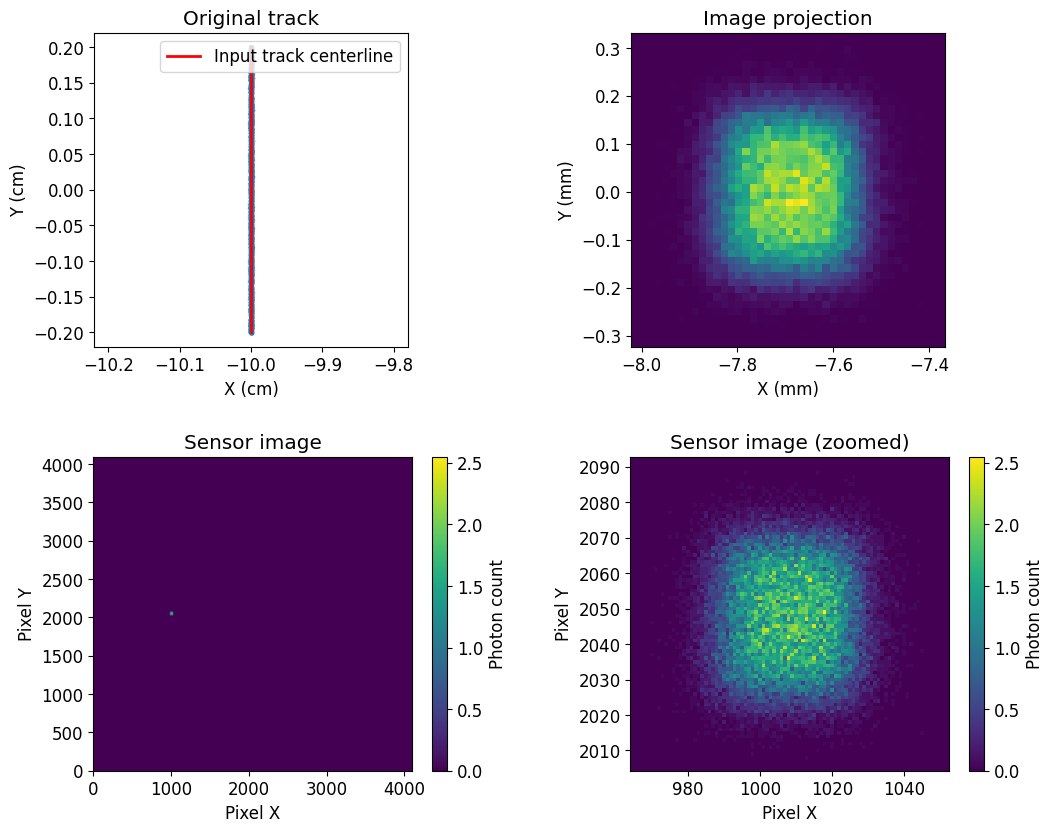

In [69]:
# --- Project and render ---
camera.ProjectPoints(aberration=True)
camera.ProduceImage()
FourPanelPlot(camera, track_x_cm, track_y_cm, upsampling_factor)

In [70]:
track_length_cm = 0.4
track_angle_phi_deg = 0
diffusion_sigma_um = 10
z_min_mm = 0.0
z_max_mm = 5.
track_offset_x_cm = 0.
track_offset_y_cm = 10.0

# Build a short vertical track in +y with uniform deposited energy per sample point.
upsampling_factor = 20
n_photons = 2500*upsampling_factor
n_track_points = 500
photons_per_energy = n_photons / n_track_points

track_y_cm = np.linspace(-track_length_cm/2, track_length_cm/2, n_track_points) + track_offset_y_cm
track_x_cm = np.full(n_track_points, track_offset_x_cm)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

source_out = camera.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=photons_per_energy,
    kernel_sigma_um=diffusion_sigma_um,
    z_min_mm=z_min_mm,
    z_max_mm=z_max_mm,
    count_mode='deterministic',
    rng_seed=123
 )

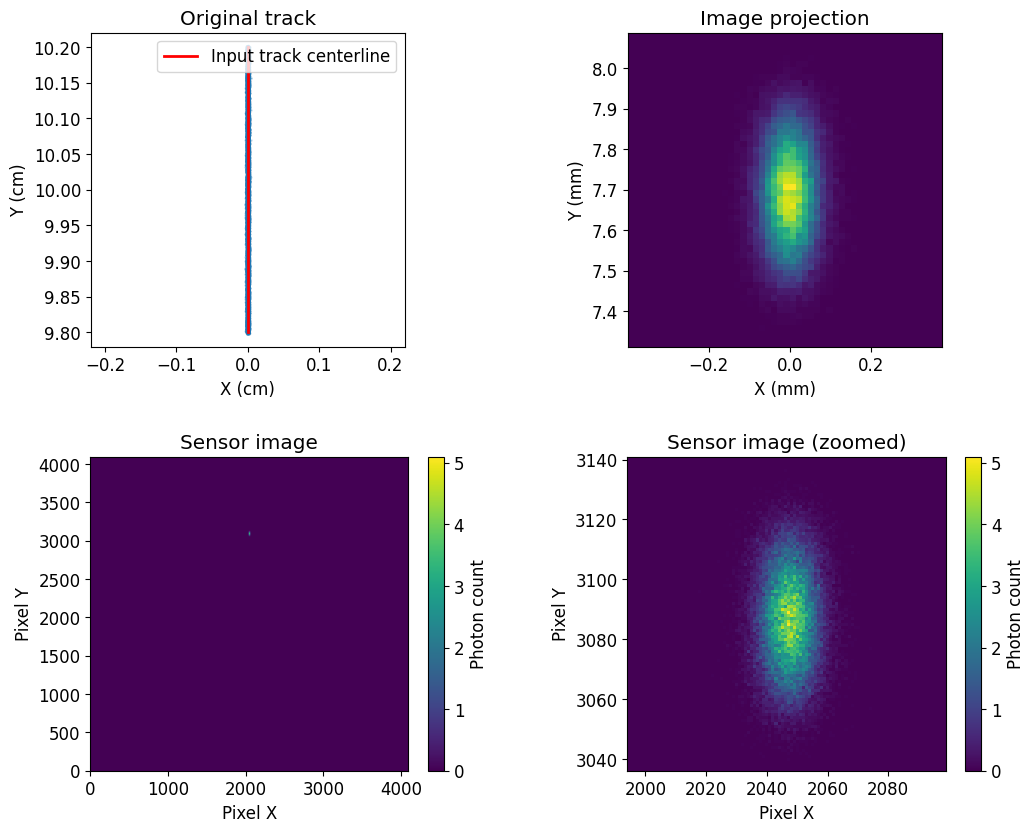

In [73]:
# --- Project and render ---
camera.ProjectPoints(aberration=True)
camera.ProduceImage()
FourPanelPlot(camera, track_x_cm, track_y_cm, upsampling_factor)

In [38]:
track_length_cm = 0.4
track_angle_phi_deg = 0
diffusion_sigma_um = 1000
z_min_mm = 0.0
z_max_mm = 5.
track_offset_x_cm = 0.0
track_offset_y_cm = 0.0

# Build a short vertical track in +y with uniform deposited energy per sample point.
upsampling_factor = 20
n_photons = 2500*upsampling_factor
n_track_points = 500
photons_per_energy = n_photons / n_track_points

track_y_cm = np.linspace(-track_length_cm/2, track_length_cm/2, n_track_points) + track_offset_y_cm
track_x_cm = np.full(n_track_points, track_offset_x_cm)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

source_out = camera.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=photons_per_energy,
    kernel_sigma_um=diffusion_sigma_um,
    z_min_mm=0.0,
    z_max_mm=0.1,
    count_mode='deterministic',
    rng_seed=123
 )
print(source_out['metadata'])

{'n_input_points': 500, 'n_valid_points': 500, 'n_generated_photons': 50000, 'count_mode': 'deterministic', 'kernel_sigma_um': 1000.0, 'z_range_mm': [0.0, 0.1], 'rng_seed': 123}


In [40]:

def FourPanelPlot(camera, track_x_cm, track_y_cm, upsampling_factor):
    # Visualize photon origins in object space (x-y).
    fig, axs = plt.subplots(2, 2, figsize=(11, 9))
    fig.subplots_adjust(left=0.10, right=0.95, bottom=0.10, top=0.92,
                        wspace=0.35, hspace=0.35)

    axs[0, 0].set_box_aspect(1)
    axs[0, 1].set_box_aspect(1)

    fig_w_in = 12
    dx_in = 0.45
    dx = dx_in / fig_w_in   # figure-fraction shift

    for ax in (axs[0, 0], axs[0, 1]):
        x0, y0, w, h = ax.get_position().bounds
        ax.set_position([x0 - dx, y0, w, h])

    axs[0, 0].scatter(camera.object_points_3d[:, 0], camera.object_points_3d[:, 1], s=0.5, alpha=0.25)
    axs[0, 0].plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Input track centerline')
    axs[0, 0].set_xlabel('X (cm)')
    axs[0, 0].set_ylabel('Y (cm)')
    axs[0, 0].set_xlim(-.5,.5)
    axs[0, 0].set_ylim(-.5,.5)
    # axs[0, 0].set_title('Sampled photon origins from simple {:2.2} cm track'.format(track_y_cm[-1] - track_y_cm[0]))
    axs[0,0].set_title('Original track')
    axs[0, 0].legend()

    axs[0,1].hist2d(camera.image_points_2d_mm[:, 0], camera.image_points_2d_mm[:, 1], bins=2000, range=[[-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm], [-camera.sensor.max_image_radius_mm, camera.sensor.max_image_radius_mm]], cmap='viridis')
    # axs[1,1].set_title('Projection of object onto the sensor plane\n (2D histogram of point density)')
    axs[0,1].set_title('Image projection')
    axs[0,1].set_xlabel('X (mm)')
    axs[0,1].set_ylabel('Y (mm)')
    axs[0,1].set_xlim(-.25,.25)
    axs[0,1].set_ylim(-.25,.25)

    im01 = axs[1,0].imshow(camera.sensor_image/upsampling_factor, origin='lower', aspect='auto')
    # axs[0,1].set_title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm Gaussian diffusion, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], diffusion_sigma_um/1000, z_max_mm-z_min_mm))
    axs[1,0].set_title('Sensor image')
    axs[1,0].set_xlabel('Pixel X')
    axs[1,0].set_ylabel('Pixel Y')
    fig.colorbar(im01, label='Photon count', ax=axs[1,0])

    im10 = axs[1,1].imshow(camera.sensor_image/upsampling_factor, origin='lower', aspect='auto')
    # axs[1,0].set_title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm Gaussian diffusion, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], diffusion_sigma_um/1000, z_max_mm-z_min_mm))
    axs[1,1].set_title('Sensor image (zoomed)')
    axs[1,1].set_xlabel('Pixel X')
    axs[1,1].set_ylabel('Pixel Y')
    axs[1,1].set_xlim(462,562)
    axs[1,1].set_ylim(462,562)
    fig.colorbar(im10, label='Photon count', ax=axs[1,1])



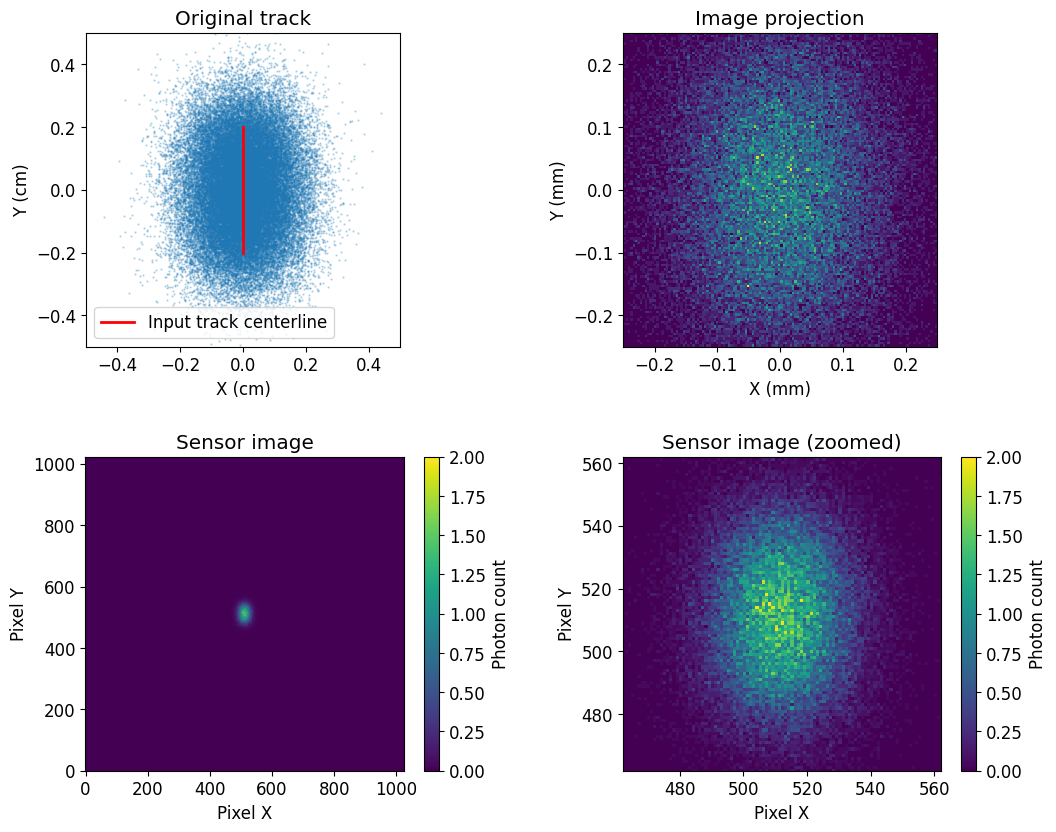

In [41]:
# --- Project and render ---
camera.ProjectPoints(aberration=True)
camera.ProduceImage()
FourPanelPlot(camera, track_x_cm, track_y_cm, upsampling_factor)